In [1]:
!pip install torchmetrics optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.2 MB/s eta 0:00:00


In [2]:
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# from pathlib import Path

# img_path = Path(r'C:\Users\user\Desktop\div\others\test\shekil.png')
# img_tensor = torchvision.io.read_image(img_path)

# print(img_tensor.dtype, img_tensor.shape)

# plt.imshow(img_tensor.permute(1, 2, 0))
# plt.show()

In [4]:
from sklearn.datasets import load_sample_images

sample_images = load_sample_images()['images']
sample_images = np.stack(sample_images)
sample_images = torch.FloatTensor(sample_images)
sample_images /= 255

In [5]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)

print(sample_images_permuted.dtype, sample_images_permuted.shape)

torch.float32 torch.Size([2, 3, 427, 640])


In [6]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1,2,0))
    plt.axis('off')

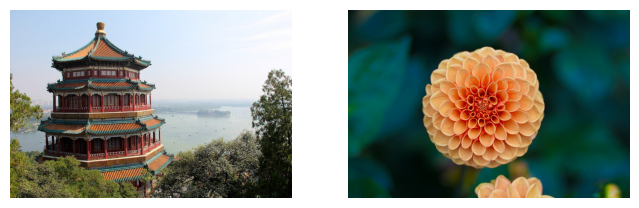

In [7]:
plt.figure(figsize=(8, 4))
for index, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(img_tensor)

In [8]:
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

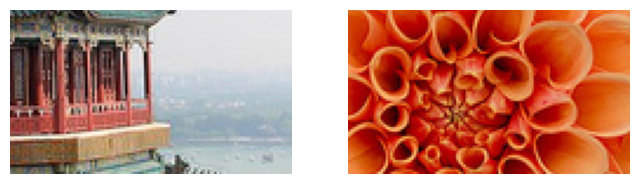

In [9]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plot_image(cropped_images[0])

plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

In [10]:
cropped_images.shape

torch.Size([2, 3, 70, 120])

In [11]:
conv_layer = nn.Conv2d(
	in_channels=3,
	out_channels=10,
	kernel_size=7,
)
conv_layer.weight.shape

torch.Size([10, 3, 7, 7])

In [12]:
output = conv_layer(cropped_images)
output.shape

torch.Size([2, 10, 64, 114])

In [13]:
output[0].shape

torch.Size([10, 64, 114])

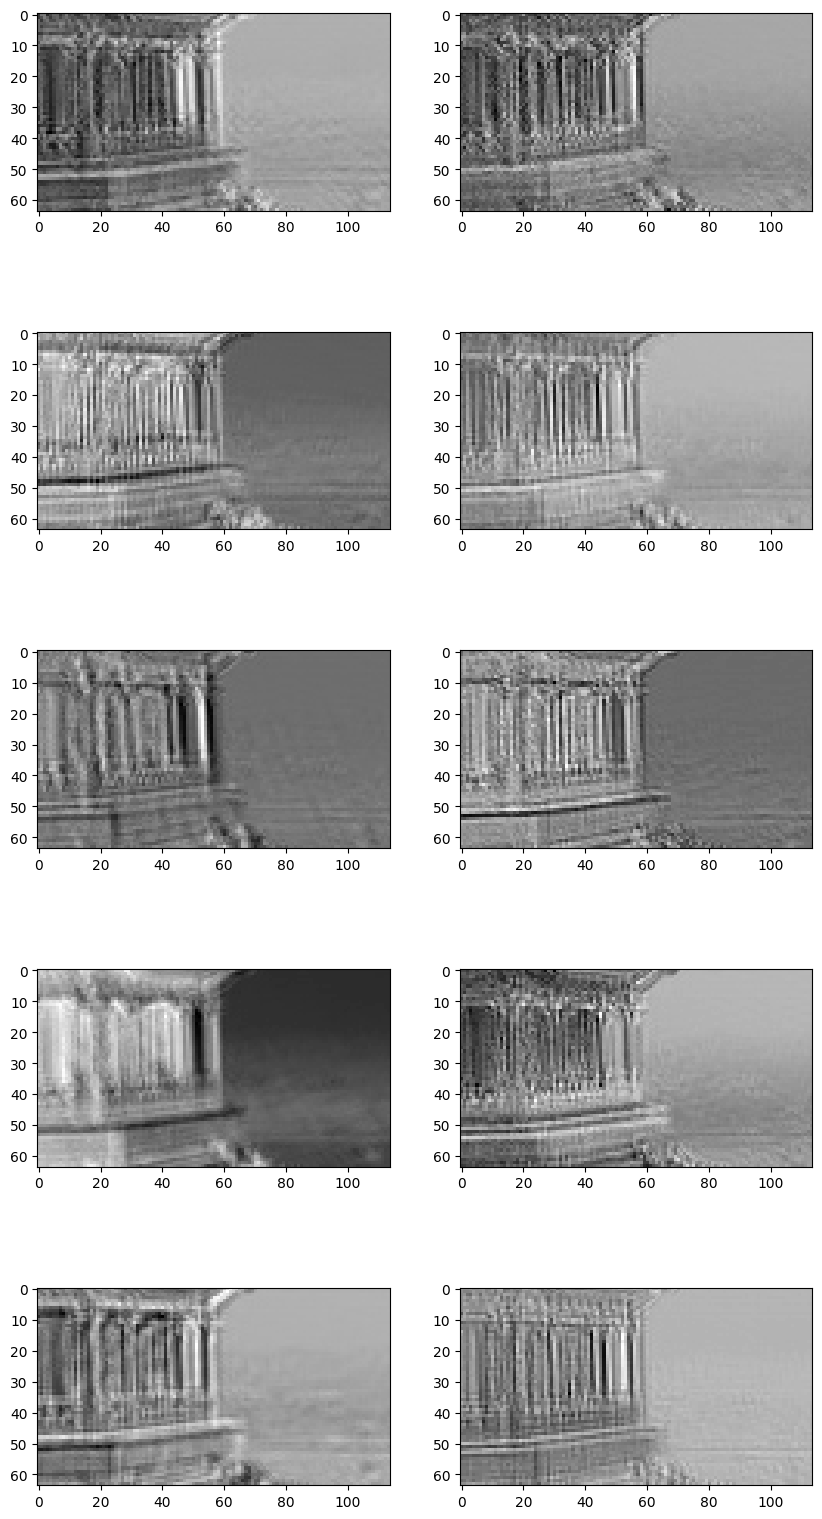

In [14]:
fig, axs = plt.subplots(5,2, figsize=(10,20))

for ind, ax in enumerate(axs.flat):
	ax.imshow(output[0][ind].detach(), cmap='gray')

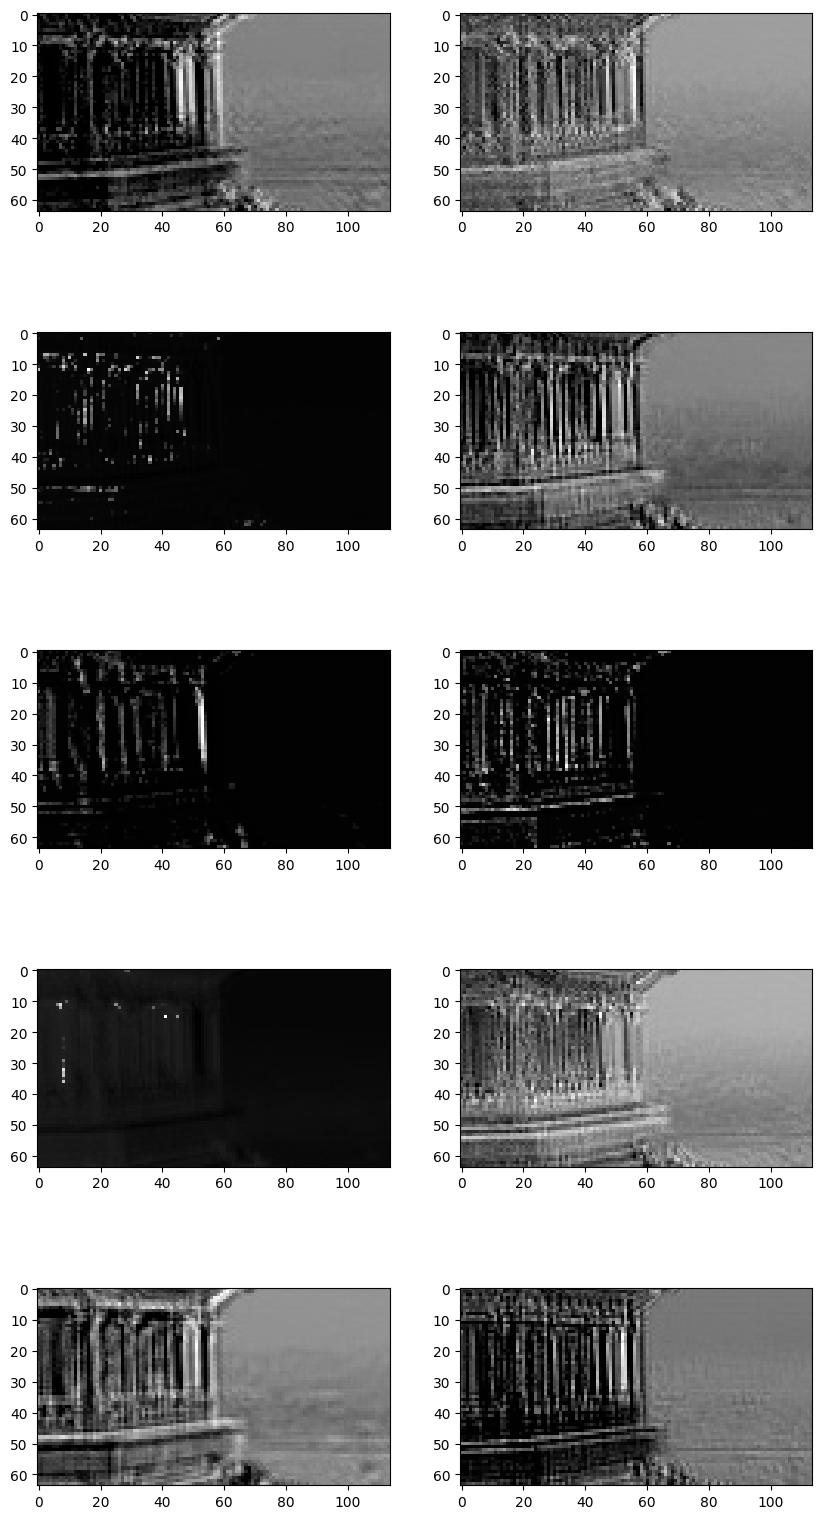

In [15]:
relu_layer = nn.LeakyReLU()
relu_output = relu_layer(output)

fig, axs = plt.subplots(5,2, figsize=(10,20))

for ind, ax in enumerate(axs.flat):
	ax.imshow(relu_output[0][ind].detach(), cmap='gray')

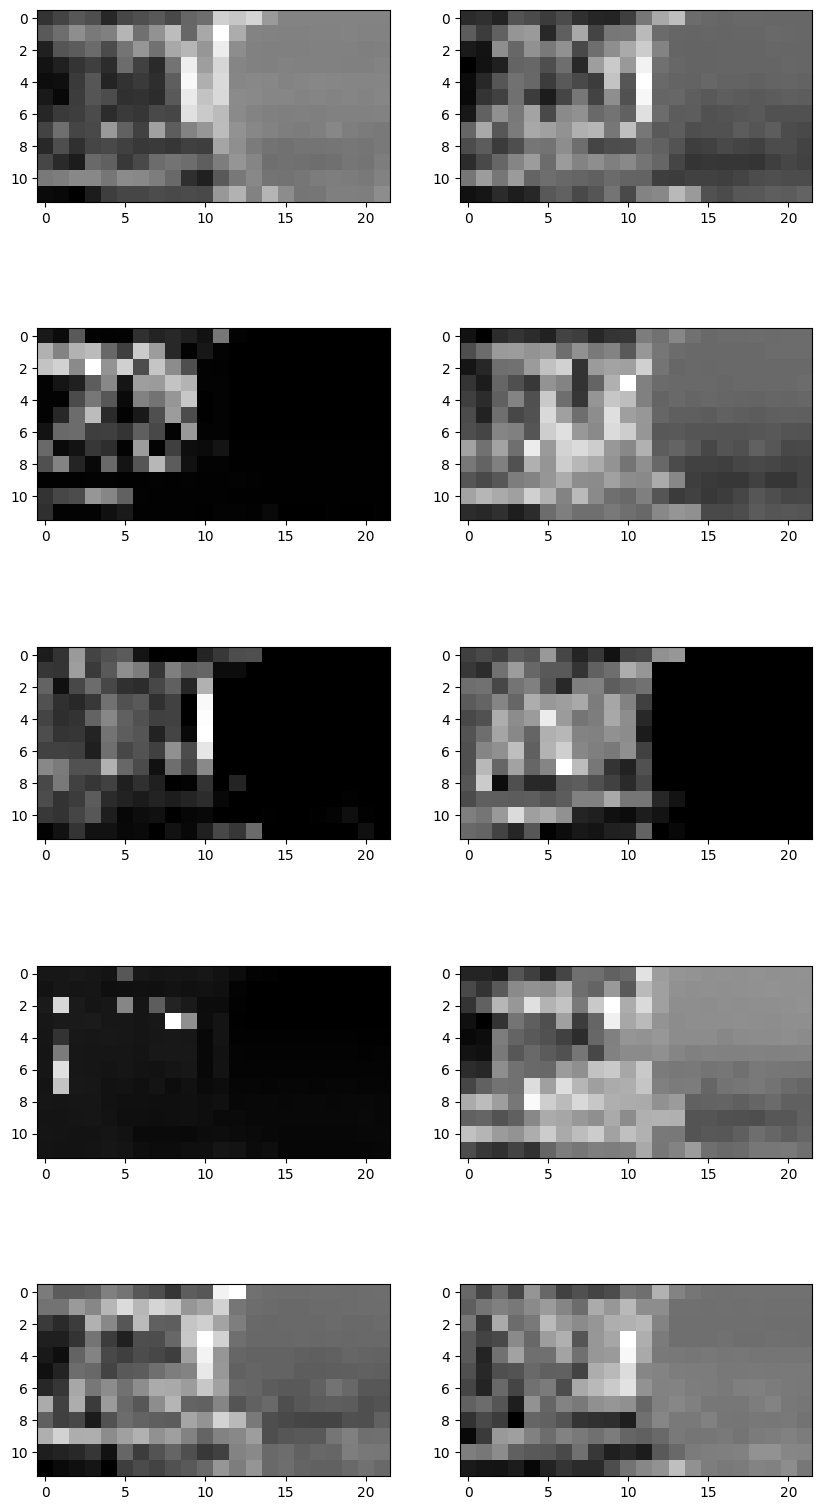

In [16]:
pooling_layer = nn.MaxPool2d(kernel_size=5)
pooling_output = pooling_layer(relu_output)

fig, axs = plt.subplots(5,2, figsize=(10,20))

for ind, ax in enumerate(axs.flat):
	ax.imshow(pooling_output[0][ind].detach(), cmap='gray')

In [17]:
cropped_images.shape

torch.Size([2, 3, 70, 120])

In [18]:
toTensor = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True)
])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="data",
	train=True,
	download=True,
	transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="data",
	train=False,
	download=True,
	transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])
# train_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])
# valid_data = torch.utils.data.Subset(train_and_valid_data, torch.randperm(len(train_and_valid_data))[:150])

from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.99MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


In [19]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [20]:
X, y = next(iter(train_loader))
X.shape

torch.Size([32, 1, 28, 28])

In [25]:
model = nn.Sequential( # [32, 1, 28, 28]
	nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding='same'), # [32, 64, 28, 28]
	nn.LeakyReLU(), # [32, 64, 28, 28]
	nn.MaxPool2d(kernel_size=2), # [32, 64, 14, 14]
	nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),  # [32, 64, 12, 12]
	nn.LeakyReLU(), # [32, 64, 12, 12]
	nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3), # [32, 128, 10, 10]
	nn.LeakyReLU(),# [32, 128, 10, 10]
	# nn.AdaptiveAvgPool2d(output_size=1)
	nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3), # [32, 256, 8, 8]
	nn.LeakyReLU(), # [32, 256, 8, 8]
	nn.MaxPool2d(kernel_size=2), # [32, 256, 4, 4]
	nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3), # [32, 256, 2, 2]
	nn.LeakyReLU(),
	nn.MaxPool2d(kernel_size=2), # [32, 256, 1, 1]
	nn.Flatten(), # [32, 256]
	nn.Linear(in_features=256,out_features=128), # [32, 128]
	nn.LeakyReLU(),
	nn.Linear(in_features=128,out_features=64), # [32, 64]
	nn.LeakyReLU(),
	nn.Linear(in_features=64,out_features=10), # [32, 10]
).to(device)

In [26]:
from custom_utils import train, plot_history

n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(
	model,
	optimizer,
	criterion,
	metric,
	train_loader,
	valid_loader,
	n_epochs,
	warmup_scheduler=None,
	scheduler=None,
	patience=None,
	checkpoint_path='fashion_mnist_model.pt',
	clip_grad_norm=None,
  device=device
)

Epoch: 1/20, Train Loss: 0.552, Train Metric: 0.791, Valid Metric: 0.854, Time: 20.99s
	Checkpoint, valid metric: 0.854
Epoch: 2/20, Train Loss: 0.33, Train Metric: 0.877, Valid Metric: 0.885, Time: 20.01s
	Checkpoint, valid metric: 0.885
Epoch: 3/20, Train Loss: 0.279, Train Metric: 0.898, Valid Metric: 0.893, Time: 20.04s
	Checkpoint, valid metric: 0.893
Epoch: 4/20, Train Loss: 0.249, Train Metric: 0.908, Valid Metric: 0.904, Time: 19.78s
	Checkpoint, valid metric: 0.904
Epoch: 5/20, Train Loss: 0.245, Train Metric: 0.911, Valid Metric: 0.9, Time: 19.24s
Epoch: 6/20, Train Loss: 0.21, Train Metric: 0.92, Valid Metric: 0.911, Time: 19.93s
	Checkpoint, valid metric: 0.911
Epoch: 7/20, Train Loss: 0.191, Train Metric: 0.928, Valid Metric: 0.905, Time: 19.12s
Epoch: 8/20, Train Loss: 0.179, Train Metric: 0.934, Valid Metric: 0.908, Time: 19.6s
Epoch: 9/20, Train Loss: 0.165, Train Metric: 0.939, Valid Metric: 0.915, Time: 19.07s
	Checkpoint, valid metric: 0.915
Epoch: 10/20, Train Loss:

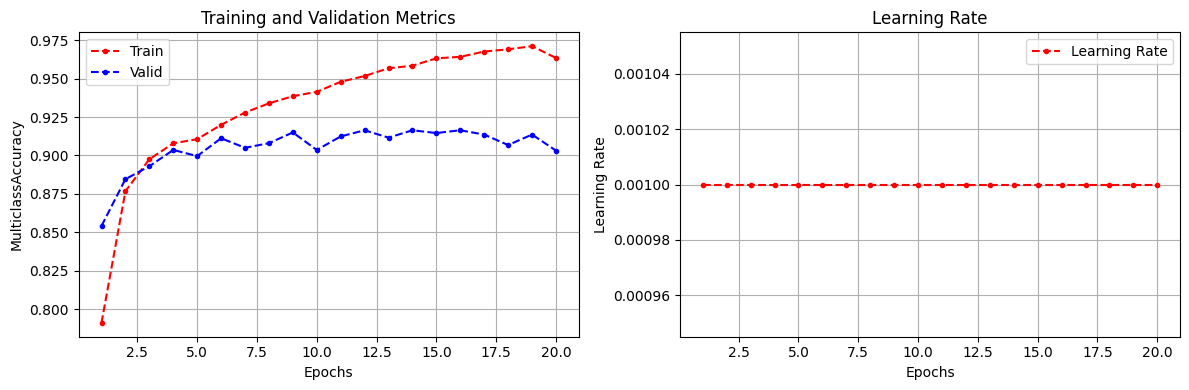

In [27]:
plot_history(history, metric)